In [ ]:
STUDENT = 'Đinh Quốc Bảo - 6351071006'

# Câu a

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import metrics

In [ ]:
import pandas as pd
df = pd.read_csv('heart.csv')
print(STUDENT)

Đinh Quốc Bảo - 6351071006


In [ ]:
initial_rows = df.shape[0]
df = df.dropna()
print(f"Removed {initial_rows - df.shape[0]} rows with missing values.")
print(f"DataFrame now has {df.shape[0]} rows and {df.shape[1]} columns.")
print(STUDENT)

Removed 0 rows with missing values.
DataFrame now has 1025 rows and 14 columns.
Đinh Quốc Bảo - 6351071006


In [ ]:
print("DataFrame before renaming:")
display(df.head())

new_column_names = df.columns

df.columns = new_column_names
display(df.head())

DataFrame before renaming:


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


# Câu 3

Đinh Quốc Bảo - 6351071006


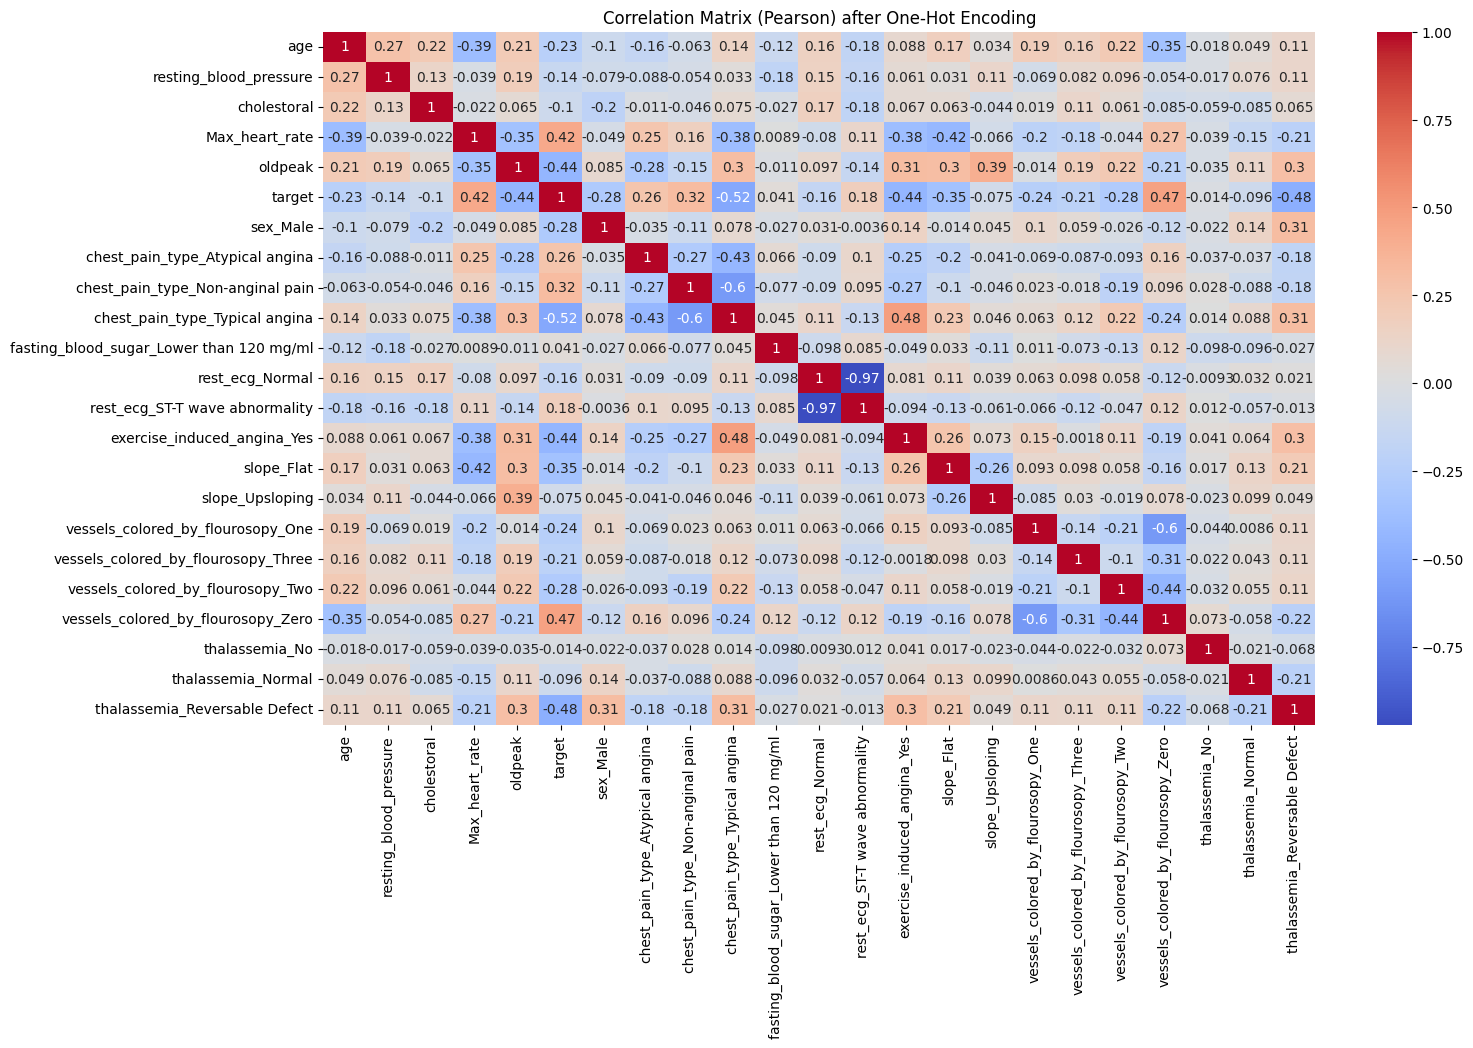

In [ ]:
print(STUDENT)

df_for_corr = df.copy()

categorical_cols = df_for_corr.select_dtypes(include='object').columns

df_encoded_for_corr = pd.get_dummies(df_for_corr, columns=categorical_cols, drop_first=True)

plt.figure(figsize=(16, 9))
sns.heatmap(df_encoded_for_corr.corr(method='pearson'), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (Pearson) after One-Hot Encoding')
plt.show()

# Câu 4

In [ ]:
print(STUDENT)
features = df.drop('target', axis= 1)
labels = df['target']

Đinh Quốc Bảo - 6351071006


# Câu 5

In [ ]:
print(STUDENT)
features.select_dtypes(exclude=['int64']).columns

Đinh Quốc Bảo - 6351071006


Index(['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'vessels_colored_by_flourosopy', 'thalassemia'],
      dtype='object')

In [ ]:
print(STUDENT)
features_onehot = pd.get_dummies(features, columns=features.select_dtypes(exclude=['int64']).columns)
features_onehot

Đinh Quốc Bảo - 6351071006


,age,resting_blood_pressure,cholestoral,Max_heart_rate,sex_Female,sex_Male,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,...,slope_Upsloping,vessels_colored_by_flourosopy_Four,vessels_colored_by_flourosopy_One,vessels_colored_by_flourosopy_Three,vessels_colored_by_flourosopy_Two,vessels_colored_by_flourosopy_Zero,thalassemia_Fixed Defect,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,52,125,212,168,False,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
1,53,140,203,155,False,True,False,False,False,True,...,True,False,False,False,False,True,False,False,False,True
2,70,145,174,125,False,True,False,False,False,True,...,True,False,False,False,False,True,False,False,False,True
3,61,148,203,161,False,True,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
4,62,138,294,106,True,False,False,False,False,True,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,140,221,164,False,True,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
1021,60,125,258,141,False,True,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
1022,47,110,275,118,False,True,False,False,False,True,...,False,False,True,False,False,False,True,False,False,False
1023,50,110,254,159,True,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False


# Câu 6

In [ ]:
from sklearn.model_selection import train_test_split

print(STUDENT)
X_train, X_test, y_train, y_test = train_test_split(features_onehot, labels, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Đinh Quốc Bảo - 6351071006
X_train shape: (820, 69)
X_test shape: (205, 69)
y_train shape: (820,)
y_test shape: (205,)


# Câu 7

In [ ]:
print(STUDENT)
lf = tree.DecisionTreeClassifier(criterion="entropy", random_state=0)
lf.fit(X_train, y_train)

Đinh Quốc Bảo - 6351071006


DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
print(STUDENT)
tree_pred = lf.predict(X_test)

tree_score = metrics.accuracy_score(y_test, tree_pred)
print("Accuracy: ", tree_score)
print("Report: ",metrics.classification_report(y_test, tree_pred))

Đinh Quốc Bảo - 6351071006
Accuracy:  0.9707317073170731
Report:                precision    recall  f1-score   support

           0       0.94      1.00      0.97       102
           1       1.00      0.94      0.97       103

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



Đinh Quốc Bảo - 6351071006


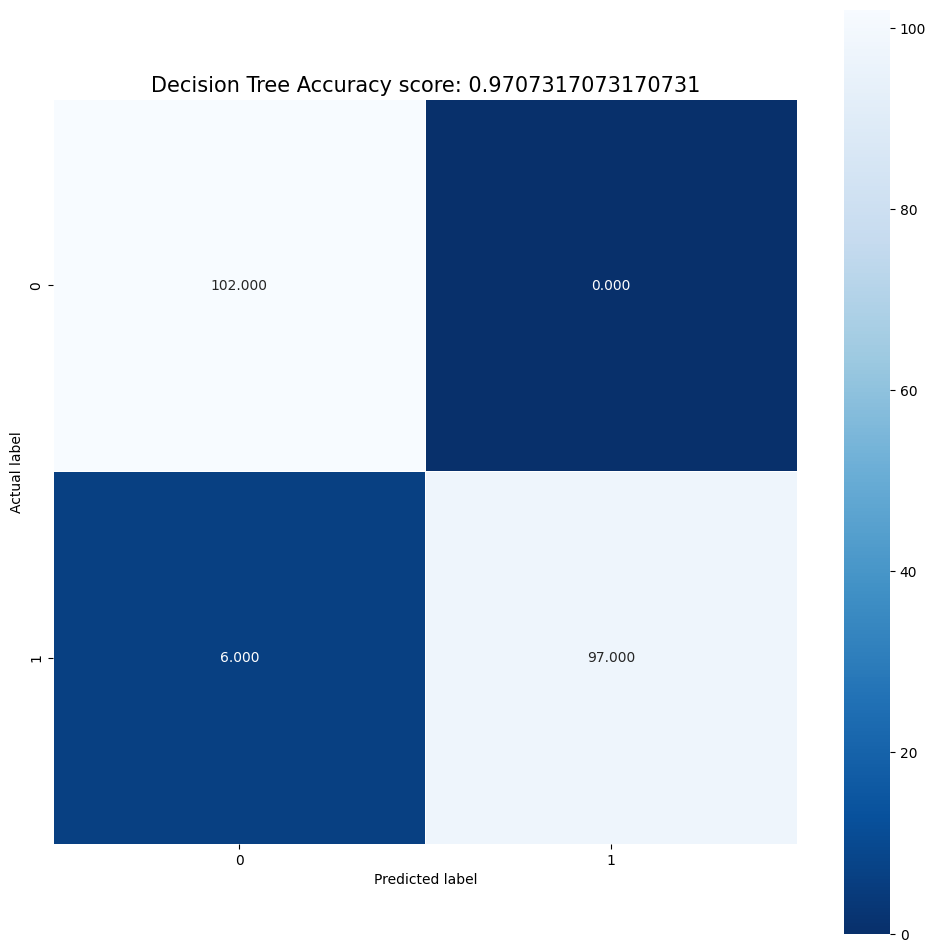

In [ ]:
print(STUDENT)

tree_cm = metrics.confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(12,12))
sns.heatmap(tree_cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'Decision Tree Accuracy score: {0}'.format(tree_score)
plt.title(title, size=15);

Đinh Quốc Bảo - 6351071006


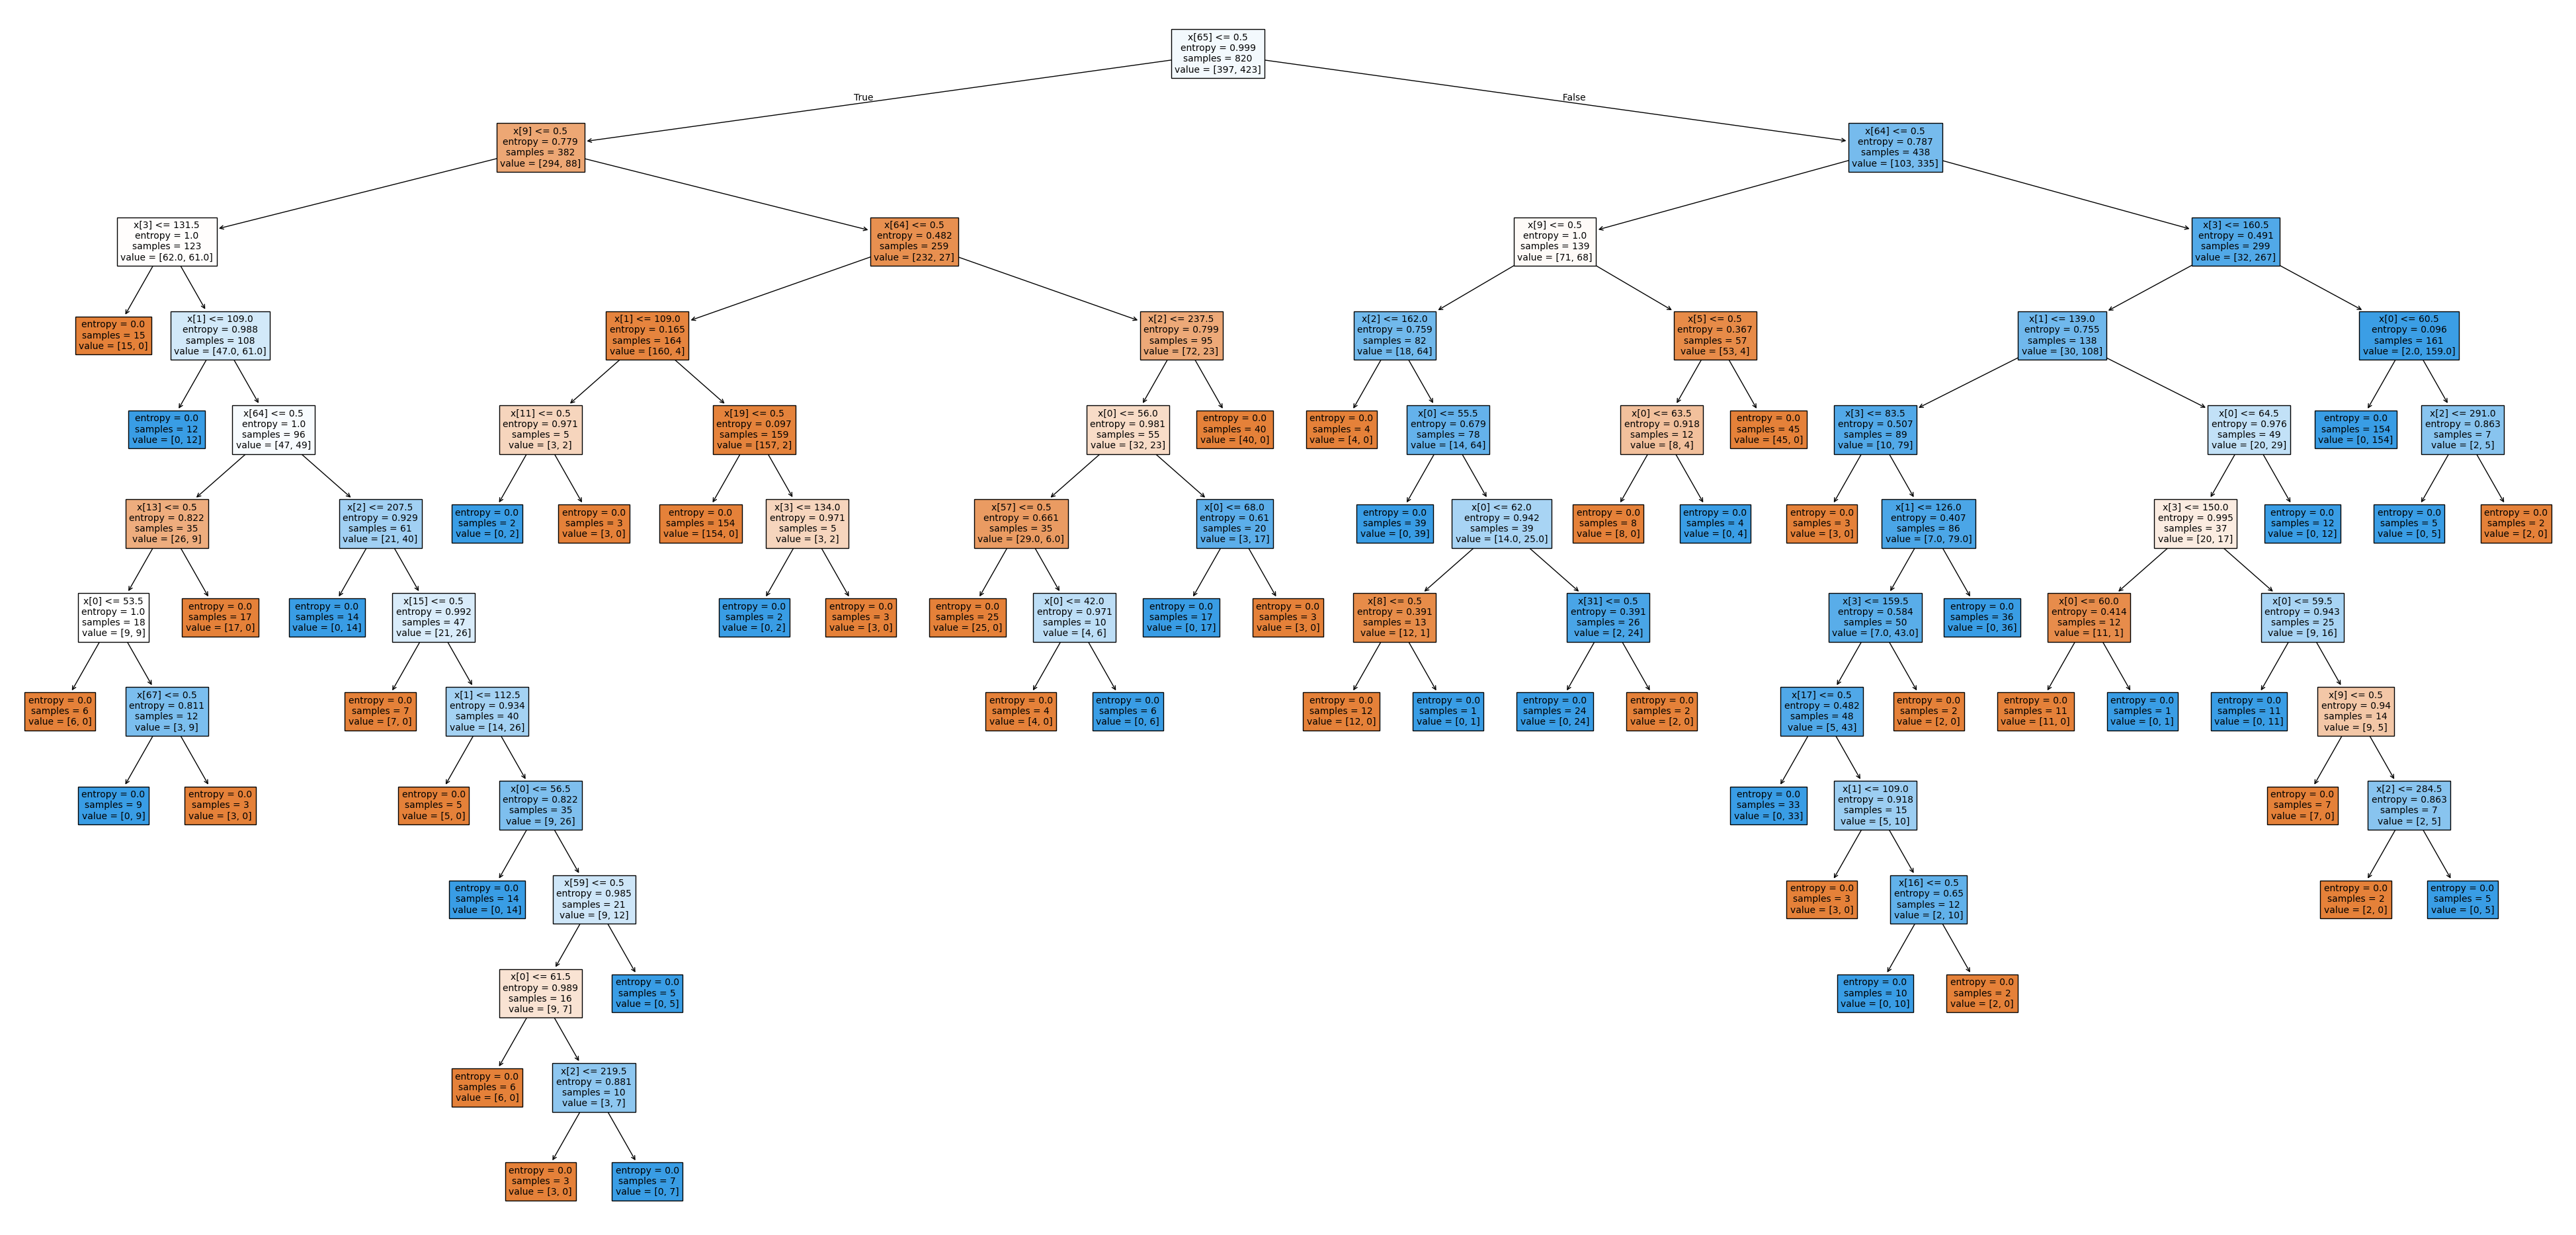

In [ ]:
print(STUDENT)
fig, ax = plt.subplots(figsize=(50, 24))
tree.plot_tree(lf, filled=True, fontsize=10) # Changed clf to lf
plt.savefig('decision_tree', dpi=100)
plt.show()

# Câu 8

In [ ]:
print(STUDENT)
clf_cart = tree.DecisionTreeClassifier(criterion="gini", random_state=0)
clf_cart.fit(X_train, y_train)

Đinh Quốc Bảo - 6351071006


DecisionTreeClassifier(random_state=0)

In [ ]:
print(STUDENT)
cart_pred = clf_cart.predict(X_test)

cart_score = metrics.accuracy_score(y_test, cart_pred)
print(f"CART Accuracy: {cart_score}")
print("CART Classification Report: ")
print(metrics.classification_report(y_test, cart_pred))

Đinh Quốc Bảo - 6351071006
CART Accuracy: 0.9707317073170731
CART Classification Report: 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       102
           1       1.00      0.94      0.97       103

    accuracy                           0.97       205
   macro avg       0.97      0.97      0.97       205
weighted avg       0.97      0.97      0.97       205



Đinh Quốc Bảo - 6351071006


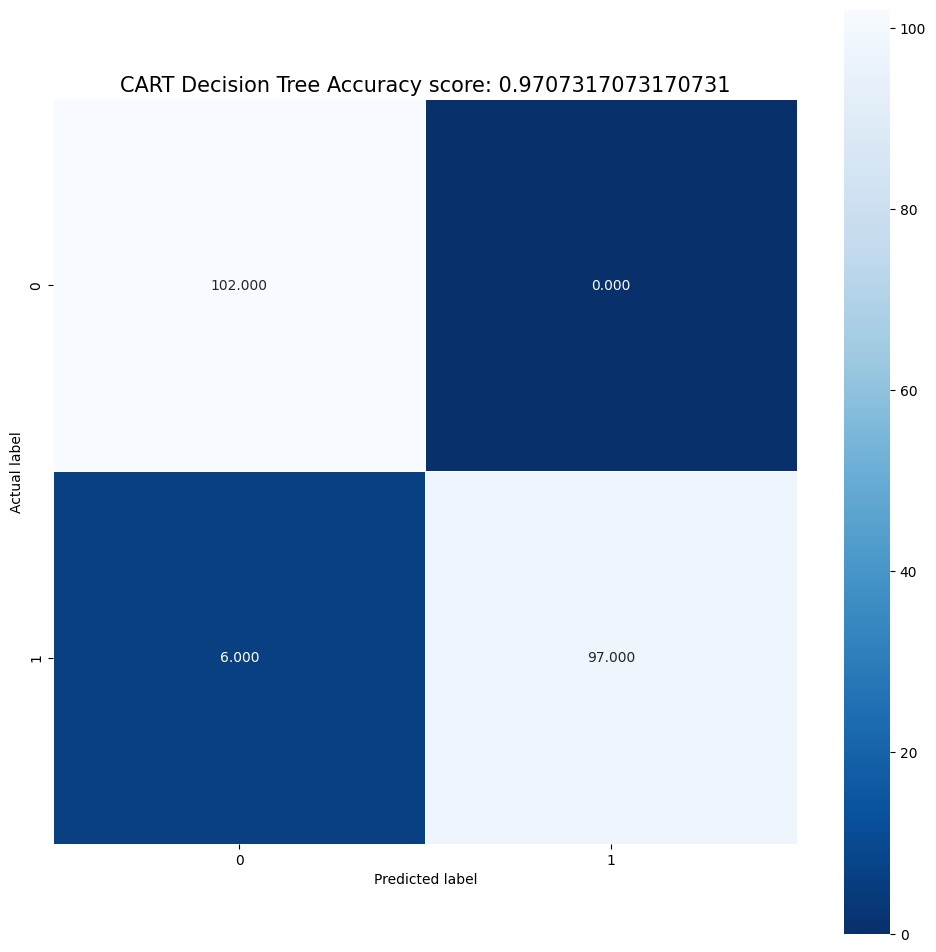

In [ ]:
print(STUDENT)
cart_cm = metrics.confusion_matrix(y_test, cart_pred)

plt.figure(figsize=(12,12))
sns.heatmap(cart_cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'CART Decision Tree Accuracy score: {0}'.format(cart_score)
plt.title(title, size=15);
plt.show()

Đinh Quốc Bảo - 6351071006


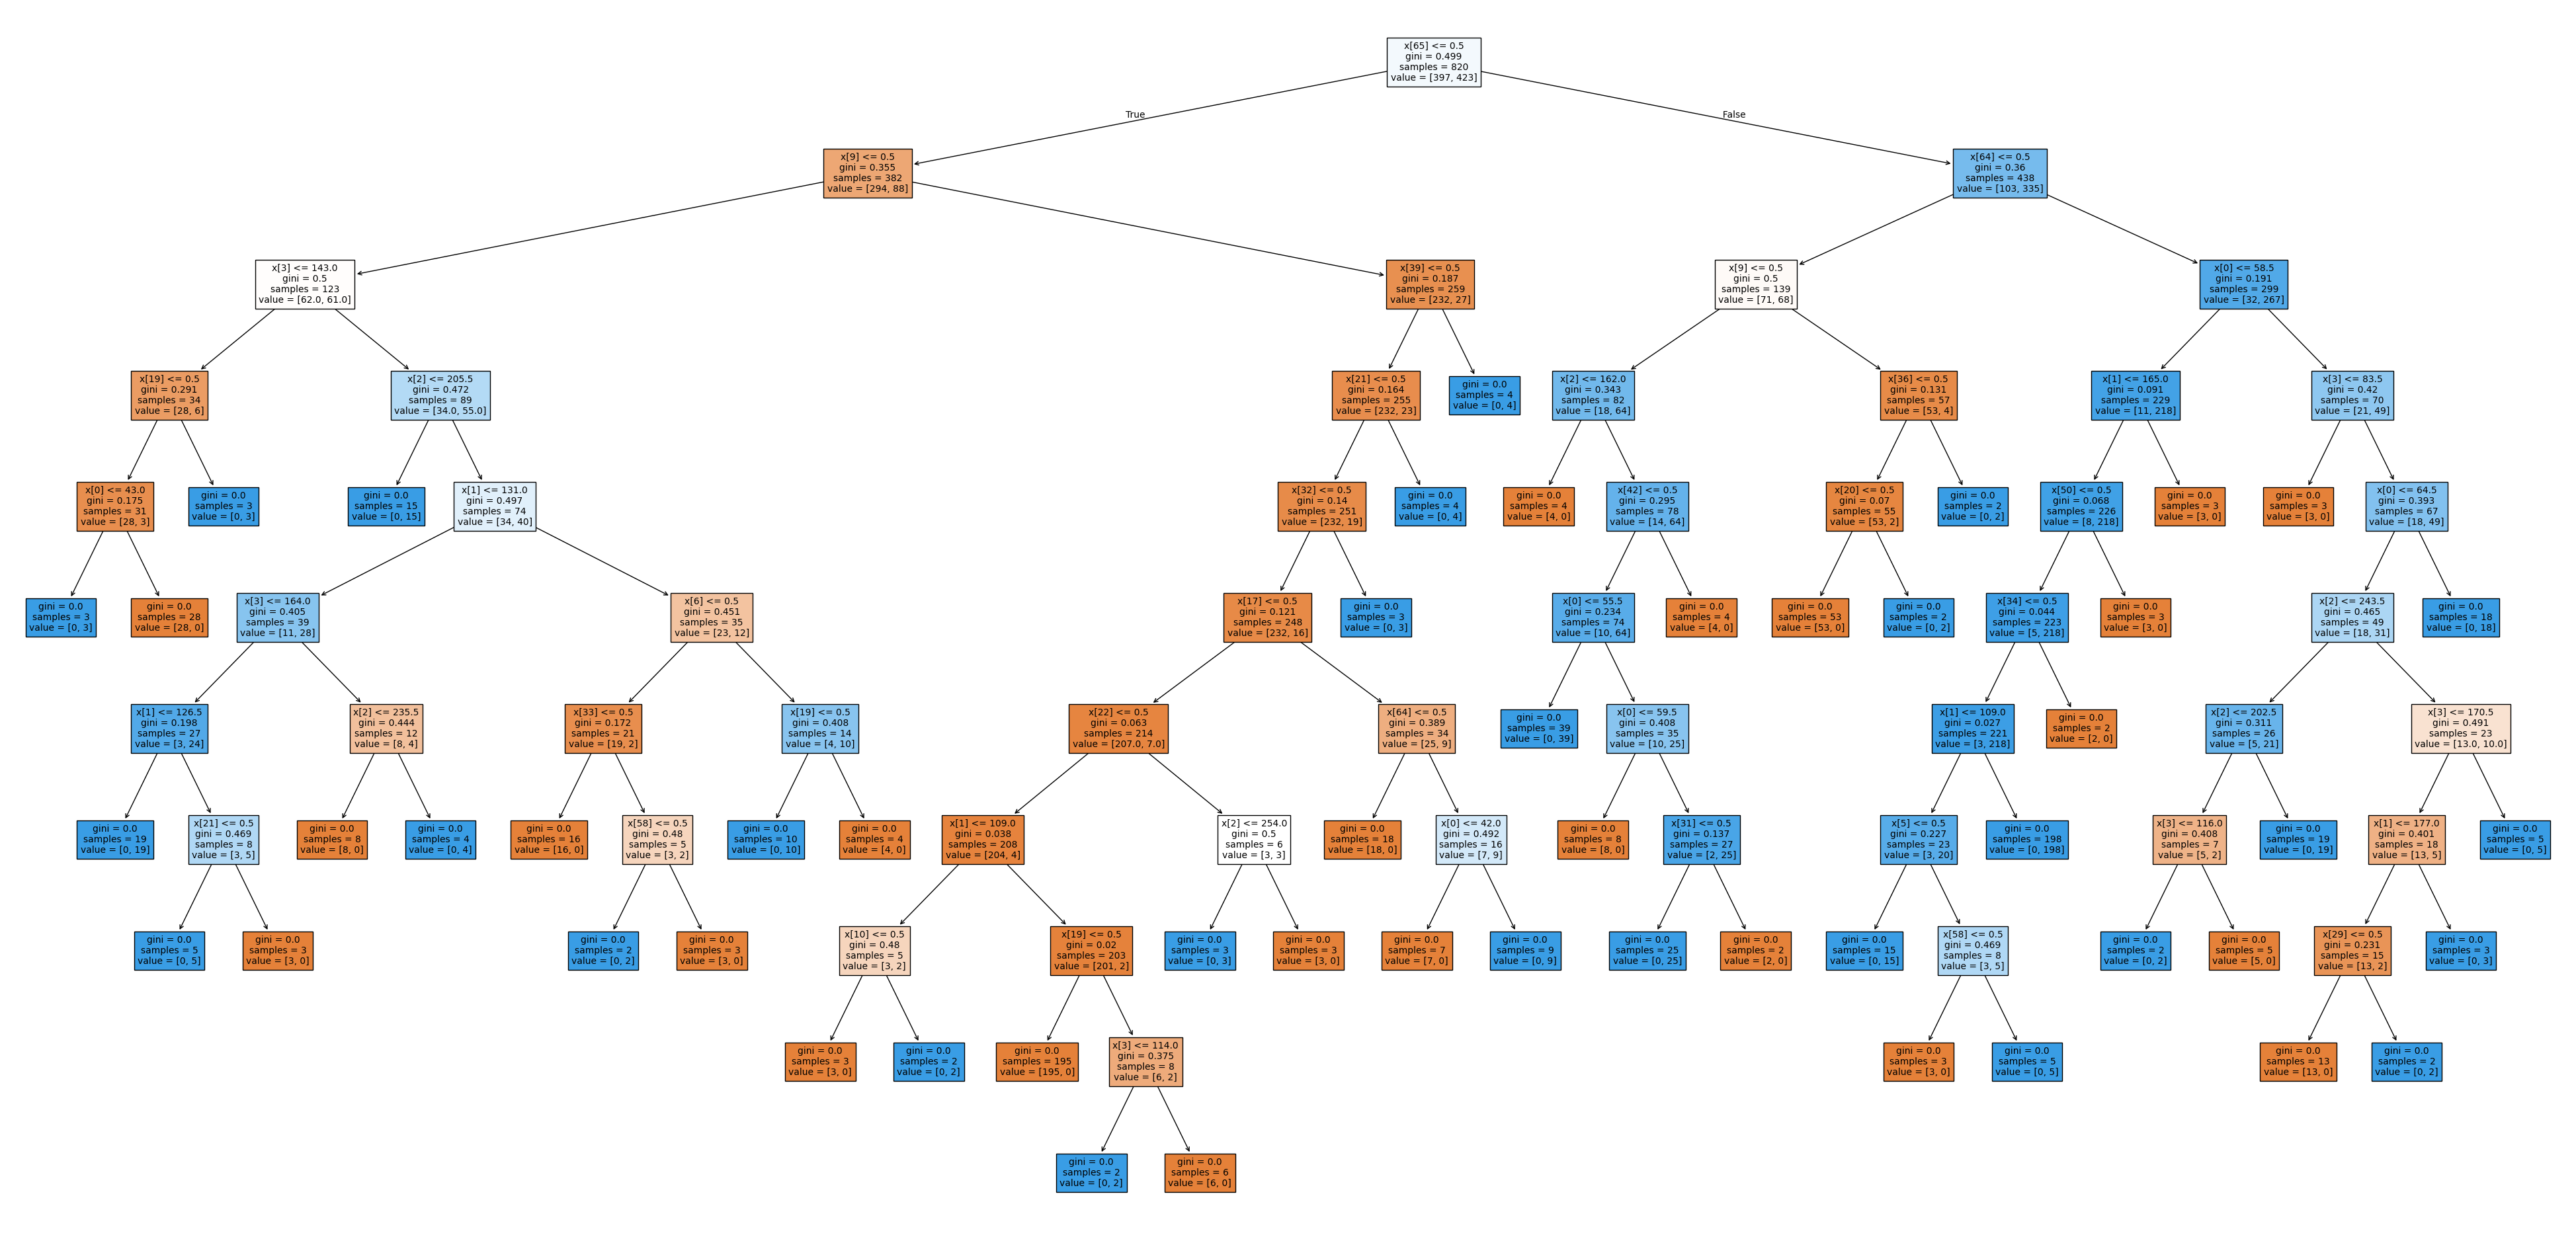

In [ ]:
print(STUDENT)
fig, ax = plt.subplots(figsize=(50, 24))
tree.plot_tree(clf_cart, filled=True, fontsize=10)
plt.savefig('cart_decision_tree', dpi=100)
plt.show()

# Câu 9

In [ ]:
print(STUDENT)
gnb = GaussianNB()
bayes_pred = gnb.fit(X_train, y_train).predict(X_test)

Đinh Quốc Bảo - 6351071006


In [ ]:
print(STUDENT)
bayes_score = metrics.accuracy_score(y_test, bayes_pred)
print(f"Naive Bayes Accuracy: {bayes_score}")
print("Naive Bayes Classification Report: ")
print(metrics.classification_report(y_test, bayes_pred))

Đinh Quốc Bảo - 6351071006
Naive Bayes Accuracy: 0.6878048780487804
Naive Bayes Classification Report: 
              precision    recall  f1-score   support

           0       0.87      0.44      0.58       102
           1       0.63      0.93      0.75       103

    accuracy                           0.69       205
   macro avg       0.75      0.69      0.67       205
weighted avg       0.75      0.69      0.67       205



Đinh Quốc Bảo - 6351071006


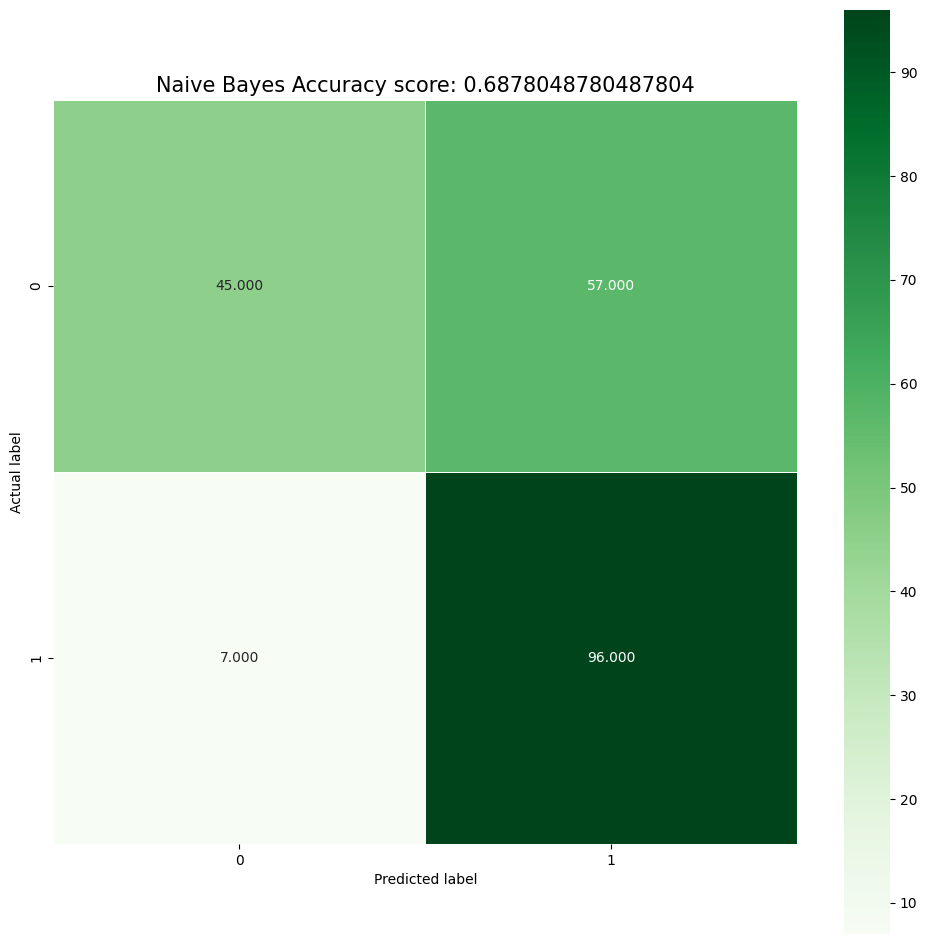

In [ ]:
print(STUDENT)
bayes_cm = metrics.confusion_matrix(y_test, bayes_pred)

plt.figure(figsize=(12,12))
sns.heatmap(bayes_cm,  annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Greens');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'Naive Bayes Accuracy score: {0}'.format(bayes_score)
plt.title(title, size=15);
#

# Câu 10

In [ ]:
print(STUDENT)

Đinh Quốc Bảo - 6351071006


- **Cây quyết định ID3 (Entropy) & CART (Gini):**  
  - Cùng đạt **Accuracy 97.07%**, kết quả **tương đương**.  
  - Phân loại lớp `0` hoàn hảo (recall 1.00), nhầm 6 mẫu lớp `1` → lớp `0`.  
  - Hiệu suất cao, ổn định, phù hợp với dữ liệu.

- **Naive Bayes (GaussianNB):**  
  - Accuracy **68.78%**, **kém xa** hai mô hình cây.  
  - Recall lớp `0` rất thấp (0.44) → bỏ sót nhiều mẫu `0`.  
  - Giả định phân phối chuẩn không phù hợp → hiệu suất giảm mạnh.

- **So sánh tổng thể:**  
  - Cây quyết định **vượt trội** Naive Bayes trên bộ dữ liệu này.  
  - ID3 và CART **không khác biệt**, đều đáng tin cậy.  
  - Naive Bayes **không phù hợp** do đặc trưng dữ liệu không chuẩn.